# MovieLens 1M Visualization

This notebook is for local data exploration only. It uses the lightweight `uv` environment from `pyproject.toml` and does not require PyTorch or PySpark.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

Matplotlib is building the font cache; this may take a moment.


## Load Data

In [2]:
DATA_DIR = Path('data')
ratings_path = DATA_DIR / 'ratings.dat'
movies_path = DATA_DIR / 'movies.dat'
users_path = DATA_DIR / 'users.dat'

missing = [str(path) for path in [ratings_path, movies_path, users_path] if not path.exists()]
if missing:
    raise FileNotFoundError(f'Missing data files: {missing}')

ratings = pd.read_csv(
    ratings_path,
    sep='::',
    engine='python',
    names=['user_id', 'movie_id', 'rating', 'timestamp'],
    encoding='latin-1',
)

movies = pd.read_csv(
    movies_path,
    sep='::',
    engine='python',
    names=['movie_id', 'title', 'genres'],
    encoding='latin-1',
)

users = pd.read_csv(
    users_path,
    sep='::',
    engine='python',
    names=['user_id', 'gender', 'age', 'occupation', 'zip_code'],
    encoding='latin-1',
)

ratings['rated_at'] = pd.to_datetime(ratings['timestamp'], unit='s')

print(f'Ratings: {len(ratings):,}')
print(f'Movies:  {len(movies):,}')
print(f'Users:   {len(users):,}')

Ratings: 1,000,209
Movies:  3,883
Users:   6,040


In [3]:
ratings.head()

,user_id,movie_id,rating,timestamp,rated_at
0,1,1193,5,978300760,2000-12-31 22:12:40
1,1,661,3,978302109,2000-12-31 22:35:09
2,1,914,3,978301968,2000-12-31 22:32:48
3,1,3408,4,978300275,2000-12-31 22:04:35
4,1,2355,5,978824291,2001-01-06 23:38:11


## Dataset Summary

In [4]:
summary = pd.DataFrame(
    {
        'metric': [
            'ratings',
            'unique users',
            'unique rated movies',
            'rating mean',
            'rating median',
            'first rating date',
            'last rating date',
        ],
        'value': [
            f'{len(ratings):,}',
            f'{ratings.user_id.nunique():,}',
            f'{ratings.movie_id.nunique():,}',
            f'{ratings.rating.mean():.3f}',
            f'{ratings.rating.median():.1f}',
            ratings.rated_at.min().date(),
            ratings.rated_at.max().date(),
        ],
    }
)
summary

,metric,value
0,ratings,"1,000,209"
1,unique users,"6,040"
2,unique rated movies,"3,706"
3,rating mean,3.582
4,rating median,4.0
5,first rating date,2000-04-25
6,last rating date,2003-02-28


## Rating Distribution

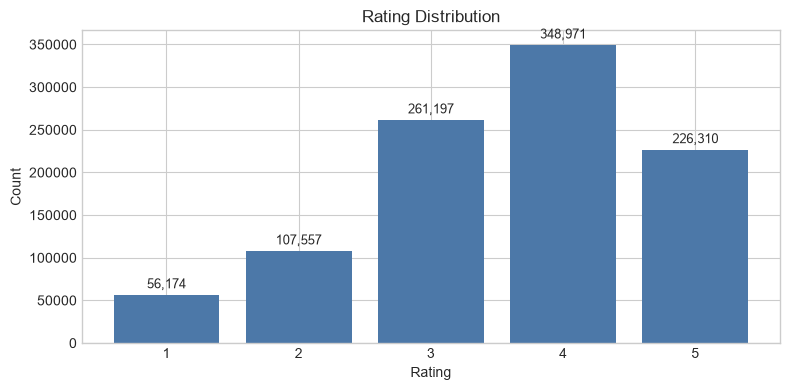

In [5]:
rating_counts = ratings['rating'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(rating_counts.index.astype(str), rating_counts.values, color='#4C78A8')
ax.set_title('Rating Distribution')
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
ax.bar_label(ax.containers[0], labels=[f'{v:,}' for v in rating_counts.values], padding=3, fontsize=9)
plt.tight_layout()

## Activity Per User And Movie

,ratings_per_user,ratings_per_movie
count,6040.000000,3706.000000
mean,165.597517,269.889099
std,192.747029,384.047838
min,20.000000,1.000000
25%,44.000000,33.000000
50%,96.000000,123.500000
75%,208.000000,350.000000
max,2314.000000,3428.000000


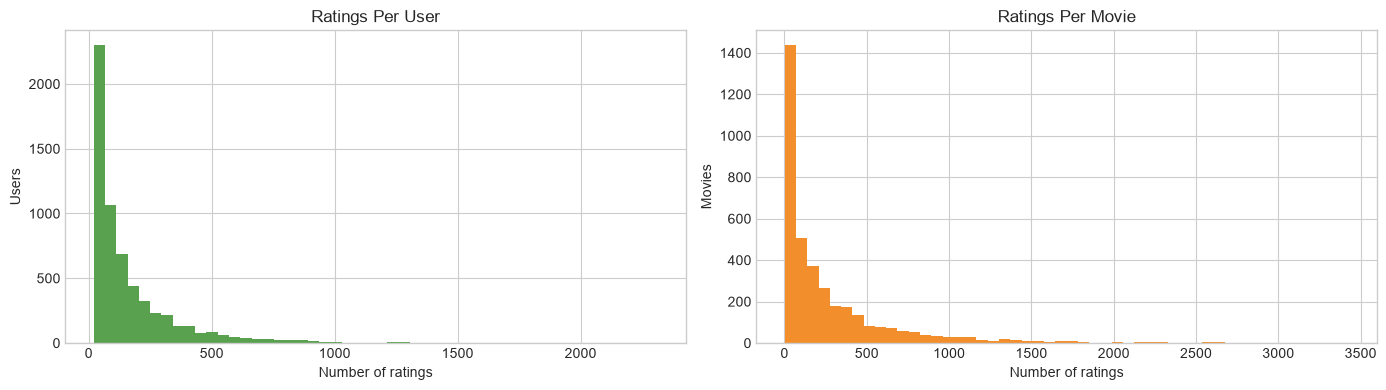

In [6]:
ratings_per_user = ratings.groupby('user_id').size()
ratings_per_movie = ratings.groupby('movie_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(ratings_per_user, bins=50, color='#59A14F')
axes[0].set_title('Ratings Per User')
axes[0].set_xlabel('Number of ratings')
axes[0].set_ylabel('Users')

axes[1].hist(ratings_per_movie, bins=50, color='#F28E2B')
axes[1].set_title('Ratings Per Movie')
axes[1].set_xlabel('Number of ratings')
axes[1].set_ylabel('Movies')

plt.tight_layout()

pd.DataFrame(
    {
        'ratings_per_user': ratings_per_user.describe(),
        'ratings_per_movie': ratings_per_movie.describe(),
    }
)

## Top Rated Movies

,title,genres,rating_count,mean_rating
1839,Seven Samurai (The Magnificent Seven) (Shichin...,Action|Drama,628,4.560510
309,"Shawshank Redemption, The (1994)",Drama,2227,4.554558
802,"Godfather, The (1972)",Action|Crime|Drama,2223,4.524966
708,"Close Shave, A (1995)",Animation|Comedy|Thriller,657,4.520548
49,"Usual Suspects, The (1995)",Crime|Thriller,1783,4.517106
513,Schindler's List (1993),Drama|War,2304,4.510417
1066,"Wrong Trousers, The (1993)",Animation|Comedy,882,4.507937
861,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Film-Noir,470,4.491489
1108,Raiders of the Lost Ark (1981),Action|Adventure,2514,4.477725
843,Rear Window (1954),Mystery|Thriller,1050,4.476190


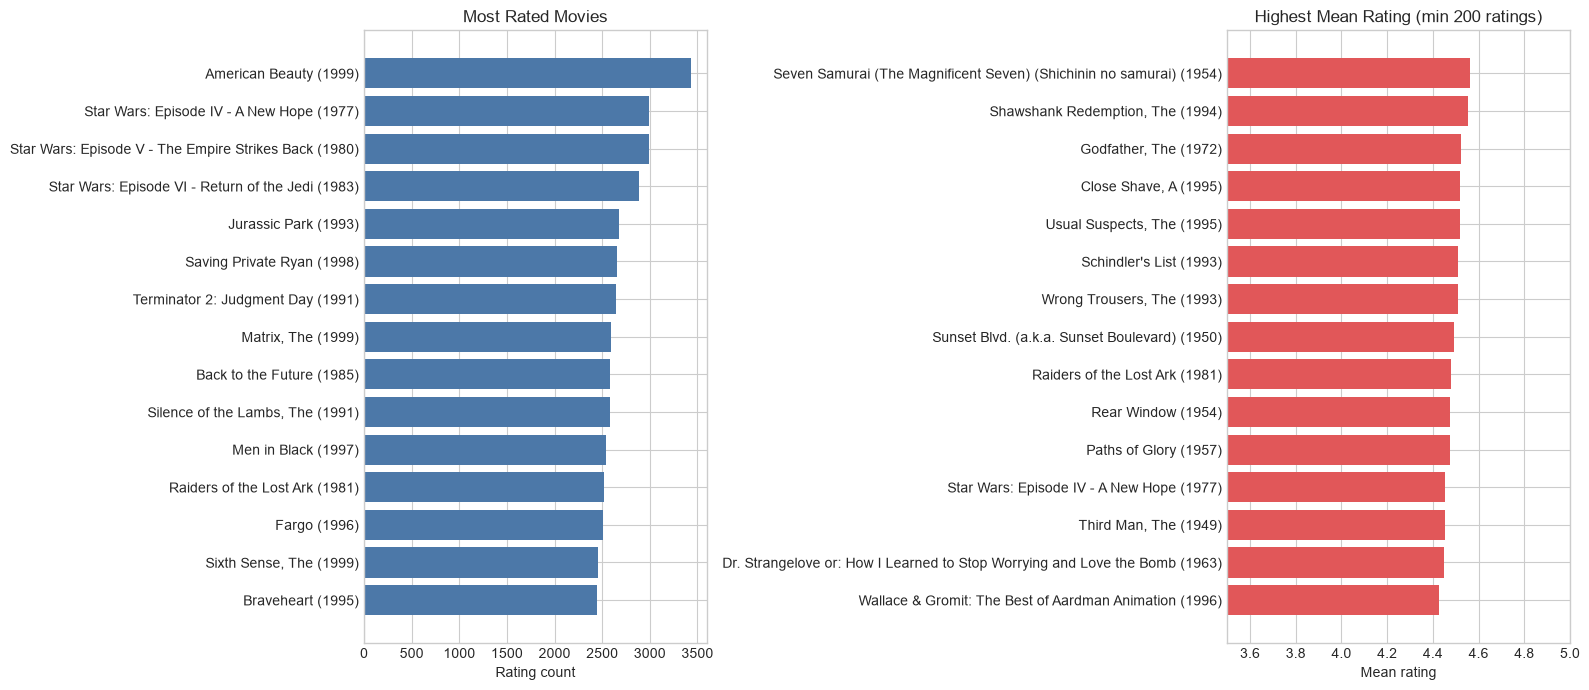

In [7]:
movie_stats = (
    ratings.groupby('movie_id')
    .agg(rating_count=('rating', 'size'), mean_rating=('rating', 'mean'))
    .reset_index()
    .merge(movies, on='movie_id', how='left')
)

popular_movies = movie_stats.sort_values('rating_count', ascending=False).head(15)
highly_rated_movies = (
    movie_stats[movie_stats['rating_count'] >= 200]
    .sort_values(['mean_rating', 'rating_count'], ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(popular_movies['title'][::-1], popular_movies['rating_count'][::-1], color='#4C78A8')
axes[0].set_title('Most Rated Movies')
axes[0].set_xlabel('Rating count')

axes[1].barh(highly_rated_movies['title'][::-1], highly_rated_movies['mean_rating'][::-1], color='#E15759')
axes[1].set_title('Highest Mean Rating (min 200 ratings)')
axes[1].set_xlabel('Mean rating')
axes[1].set_xlim(3.5, 5.0)

plt.tight_layout()
highly_rated_movies[['title', 'genres', 'rating_count', 'mean_rating']]

## Genre Counts

,movie_count
genre,
Drama,1603
Comedy,1200
Action,503
Thriller,492
Romance,471
Horror,343
Adventure,283
Sci-Fi,276
Children's,251


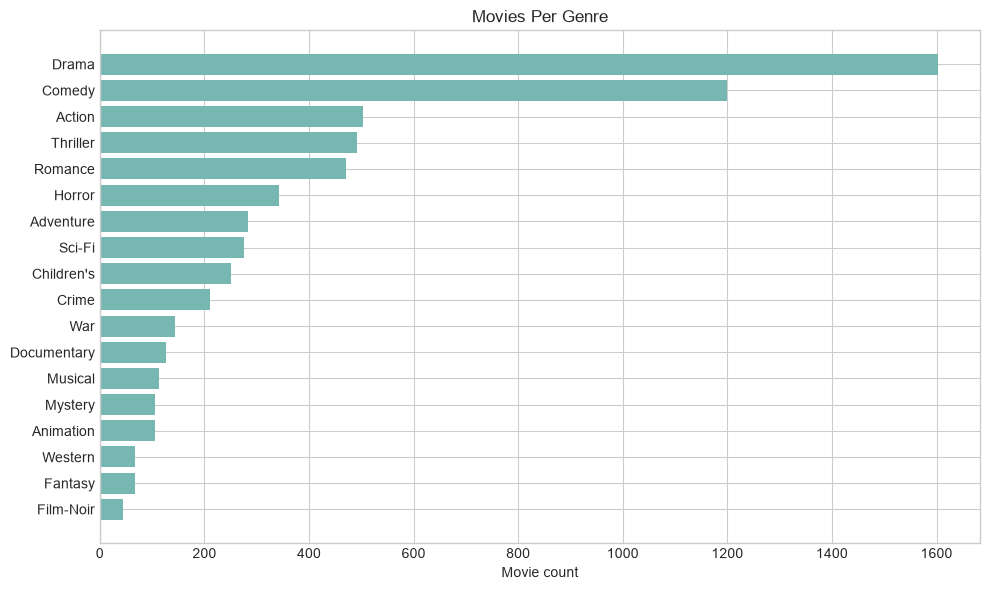

In [8]:
genres = movies.assign(genre=movies['genres'].str.split('|')).explode('genre')
genre_counts = genres['genre'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(genre_counts.index, genre_counts.values, color='#76B7B2')
ax.set_title('Movies Per Genre')
ax.set_xlabel('Movie count')
plt.tight_layout()

genre_counts.sort_values(ascending=False).to_frame('movie_count')

## User Demographics

,user_id,gender,age_label,occupation_label,zip_code
0,1,F,Under 18,K-12 student,48067
1,2,M,56+,self-employed,70072
2,3,M,25-34,scientist,55117
3,4,M,45-49,executive/managerial,02460
4,5,M,25-34,writer,55455


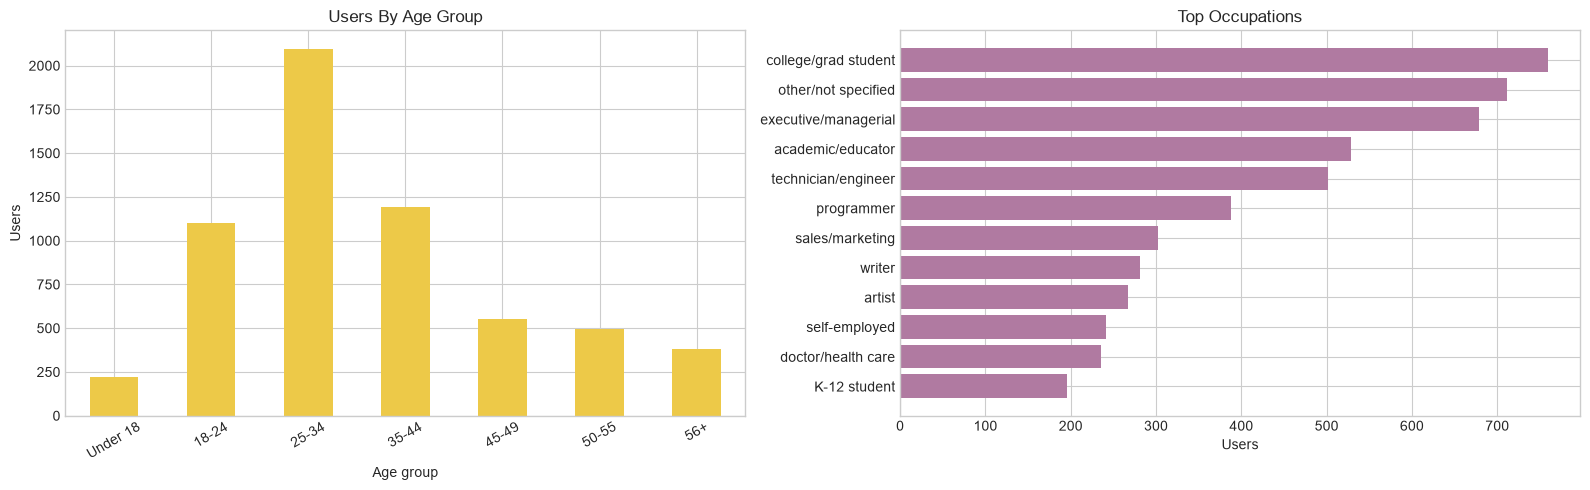

In [9]:
age_labels = {
    1: 'Under 18',
    18: '18-24',
    25: '25-34',
    35: '35-44',
    45: '45-49',
    50: '50-55',
    56: '56+',
}

occupation_labels = {
    0: 'other/not specified',
    1: 'academic/educator',
    2: 'artist',
    3: 'clerical/admin',
    4: 'college/grad student',
    5: 'customer service',
    6: 'doctor/health care',
    7: 'executive/managerial',
    8: 'farmer',
    9: 'homemaker',
    10: 'K-12 student',
    11: 'lawyer',
    12: 'programmer',
    13: 'retired',
    14: 'sales/marketing',
    15: 'scientist',
    16: 'self-employed',
    17: 'technician/engineer',
    18: 'tradesman/craftsman',
    19: 'unemployed',
    20: 'writer',
}

users_viz = users.copy()
users_viz['age_label'] = users_viz['age'].map(age_labels)
users_viz['occupation_label'] = users_viz['occupation'].map(occupation_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

users_viz['age_label'].value_counts().reindex(age_labels.values()).plot(kind='bar', ax=axes[0], color='#EDC948')
axes[0].set_title('Users By Age Group')
axes[0].set_xlabel('Age group')
axes[0].set_ylabel('Users')
axes[0].tick_params(axis='x', rotation=30)

occupation_counts = users_viz['occupation_label'].value_counts().sort_values().tail(12)
axes[1].barh(occupation_counts.index, occupation_counts.values, color='#B07AA1')
axes[1].set_title('Top Occupations')
axes[1].set_xlabel('Users')

plt.tight_layout()

users_viz[['user_id', 'gender', 'age_label', 'occupation_label', 'zip_code']].head()

## Ratings Over Time

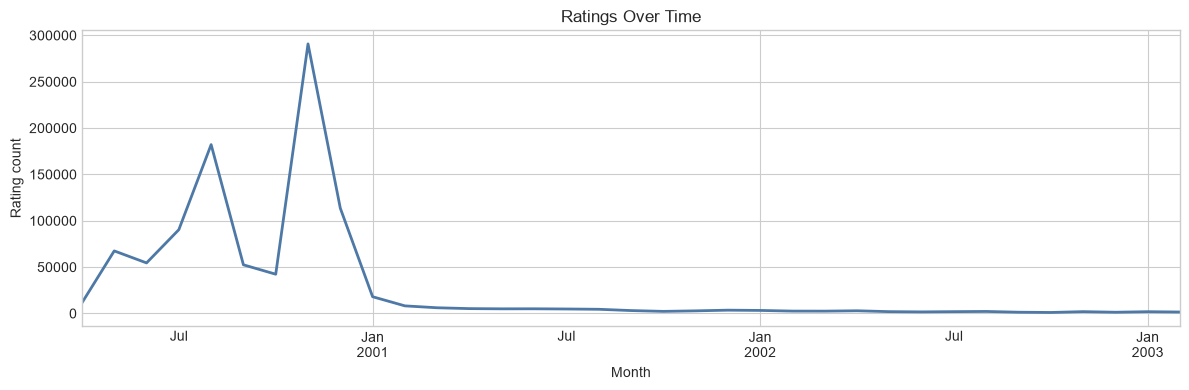

In [10]:
monthly_ratings = ratings.set_index('rated_at').resample('ME').size()

fig, ax = plt.subplots(figsize=(12, 4))
monthly_ratings.plot(ax=ax, color='#4E79A7', linewidth=2)
ax.set_title('Ratings Over Time')
ax.set_xlabel('Month')
ax.set_ylabel('Rating count')
plt.tight_layout()